In [1]:
import os
from pathlib import Path
import math
import json

import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
BASE_PATH = Path(r"E:\Thesis")

HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

OUT_DIR = BASE_PATH / "outputs" / "dataset_characterization"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

print("Output folder:", OUT_DIR)

Output folder: E:\Thesis\outputs\dataset_characterization


In [3]:
ham = pd.read_csv(HAM_PATH / "HAM10000_metadata.csv")
pad = pd.read_csv(PAD_PATH / "metadata.csv")

print("HAM shape:", ham.shape)
print("PAD shape:", pad.shape)

print(ham.columns.tolist())
print(pad.columns.tolist())

HAM shape: (10015, 8)
PAD shape: (2298, 26)
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']
['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']


In [4]:
HAM_CLASSES = ["akiec", "bcc", "mel", "nv"]
PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

ham_4 = ham[ham["dx"].isin(HAM_CLASSES)].copy()
ham_4["label"] = ham_4["dx"].map({
    "akiec": "ACK",
    "bcc": "BCC",
    "mel": "MEL",
    "nv": "NEV"
})

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]

print("HAM class counts:")
print(ham_4["label"].value_counts())

print("\nPAD class counts:")
print(pad_4["label"].value_counts())

HAM class counts:
label
NEV    6705
MEL    1113
BCC     514
ACK     327
Name: count, dtype: int64

PAD class counts:
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [5]:
ham_4["image_path"] = ham_4["image_id"].apply(lambda x: str(HAM_IMAGE_DIR / f"{x}.jpg"))
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))

ham_4["exists"] = ham_4["image_path"].apply(os.path.exists)
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print("HAM exists:")
print(ham_4["exists"].value_counts())

print("\nPAD exists:")
print(pad_4["exists"].value_counts())

HAM exists:
exists
True    8659
Name: count, dtype: int64

PAD exists:
exists
True    1871
Name: count, dtype: int64


In [6]:
print("HAM labels:", sorted(ham_4["label"].unique()))
print("PAD labels:", sorted(pad_4["label"].unique()))
print("Same classes:", set(ham_4["label"].unique()) == set(pad_4["label"].unique()))

HAM labels: ['ACK', 'BCC', 'MEL', 'NEV']
PAD labels: ['ACK', 'BCC', 'MEL', 'NEV']
Same classes: True


In [7]:
def image_stats(image_path):
    """
    Returns:
    - width, height, aspect_ratio
    - mean RGB
    - brightness (luminance)
    - contrast (std of luminance)
    - HSV mean
    - Lab mean
    """
    try:
        img = Image.open(image_path).convert("RGB")
        arr = np.array(img)  # RGB, shape (H, W, 3)
        
        h, w = arr.shape[:2]
        aspect_ratio = w / h if h != 0 else np.nan

        # RGB means
        r_mean = float(arr[:, :, 0].mean())
        g_mean = float(arr[:, :, 1].mean())
        b_mean = float(arr[:, :, 2].mean())

        # Brightness / luminance
        luminance = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
        brightness_mean = float(luminance.mean())
        contrast = float(luminance.std())

        # HSV
        rgb_uint8 = arr.astype(np.uint8)
        hsv = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2HSV)
        h_mean = float(hsv[:, :, 0].mean())
        s_mean = float(hsv[:, :, 1].mean())
        v_mean = float(hsv[:, :, 2].mean())

        # Lab
        lab = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2LAB)
        l_mean = float(lab[:, :, 0].mean())
        a_mean = float(lab[:, :, 1].mean())
        b_lab_mean = float(lab[:, :, 2].mean())

        return {
            "width": w,
            "height": h,
            "aspect_ratio": aspect_ratio,
            "mean_r": r_mean,
            "mean_g": g_mean,
            "mean_b": b_mean,
            "brightness_mean": brightness_mean,
            "contrast": contrast,
            "h_mean": h_mean,
            "s_mean": s_mean,
            "v_mean": v_mean,
            "lab_l_mean": l_mean,
            "lab_a_mean": a_mean,
            "lab_b_mean": b_lab_mean
        }

    except Exception as e:
        return {
            "width": np.nan,
            "height": np.nan,
            "aspect_ratio": np.nan,
            "mean_r": np.nan,
            "mean_g": np.nan,
            "mean_b": np.nan,
            "brightness_mean": np.nan,
            "contrast": np.nan,
            "h_mean": np.nan,
            "s_mean": np.nan,
            "v_mean": np.nan,
            "lab_l_mean": np.nan,
            "lab_a_mean": np.nan,
            "lab_b_mean": np.nan,
            "error": str(e)
        }

In [8]:
def characterize_dataset(df, dataset_name):
    """
    Adds per-image stats to a dataframe and saves summary CSV.
    """
    records = []
    total = len(df)

    for i, (_, row) in enumerate(df.iterrows(), start=1):
        path = row["image_path"]
        stats = image_stats(path)
        rec = row.to_dict()
        rec.update(stats)
        records.append(rec)

        if i % 200 == 0 or i == total:
            print(f"{dataset_name}: processed {i}/{total}")

    out_df = pd.DataFrame(records)
    out_df["dataset"] = dataset_name

    out_csv = OUT_DIR / f"{dataset_name.lower()}_characterized.csv"
    out_df.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")

    return out_df

In [9]:
ham_stats = characterize_dataset(ham_4[ham_4["exists"] == True].copy(), "HAM10000")
pad_stats = characterize_dataset(pad_4[pad_4["exists"] == True].copy(), "PAD_UFES_20")

print(ham_stats.shape, pad_stats.shape)

HAM10000: processed 200/8659
HAM10000: processed 400/8659
HAM10000: processed 600/8659
HAM10000: processed 800/8659
HAM10000: processed 1000/8659
HAM10000: processed 1200/8659
HAM10000: processed 1400/8659
HAM10000: processed 1600/8659
HAM10000: processed 1800/8659
HAM10000: processed 2000/8659
HAM10000: processed 2200/8659
HAM10000: processed 2400/8659
HAM10000: processed 2600/8659
HAM10000: processed 2800/8659
HAM10000: processed 3000/8659
HAM10000: processed 3200/8659
HAM10000: processed 3400/8659
HAM10000: processed 3600/8659
HAM10000: processed 3800/8659
HAM10000: processed 4000/8659
HAM10000: processed 4200/8659
HAM10000: processed 4400/8659
HAM10000: processed 4600/8659
HAM10000: processed 4800/8659
HAM10000: processed 5000/8659
HAM10000: processed 5200/8659
HAM10000: processed 5400/8659
HAM10000: processed 5600/8659
HAM10000: processed 5800/8659
HAM10000: processed 6000/8659
HAM10000: processed 6200/8659
HAM10000: processed 6400/8659
HAM10000: processed 6600/8659
HAM10000: proc

In [10]:
all_stats = pd.concat([ham_stats, pad_stats], ignore_index=True)
all_stats.to_csv(OUT_DIR / "all_datasets_characterized.csv", index=False)

print(all_stats.head())

     lesion_id      image_id   dx    dx_type   age     sex     localization  \
0  HAM_0001751  ISIC_0024698   nv  consensus  70.0    male             face   
1  HAM_0000559  ISIC_0024693   nv  follow_up  45.0  female  upper extremity   
2  HAM_0000871  ISIC_0025964  mel      histo  40.0  female            chest   
3  HAM_0000871  ISIC_0030623  mel      histo  40.0  female            chest   
4  HAM_0000040  ISIC_0027190  mel      histo  80.0    male  upper extremity   

    dataset label                                  image_path  ...  \
0  HAM10000   NEV  E:\Thesis\HAM10000\images\ISIC_0024698.jpg  ...   
1  HAM10000   NEV  E:\Thesis\HAM10000\images\ISIC_0024693.jpg  ...   
2  HAM10000   MEL  E:\Thesis\HAM10000\images\ISIC_0025964.jpg  ...   
3  HAM10000   MEL  E:\Thesis\HAM10000\images\ISIC_0030623.jpg  ...   
4  HAM10000   MEL  E:\Thesis\HAM10000\images\ISIC_0027190.jpg  ...   

   diameter_2  diagnostic  itch  grew  hurt  changed  bleed  elevation  \
0         NaN         NaN   Na

In [11]:
summary = all_stats.groupby("dataset").agg(
    num_images=("image_path", "count"),
    mean_r=("mean_r", "mean"),
    std_r=("mean_r", "std"),
    mean_g=("mean_g", "mean"),
    std_g=("mean_g", "std"),
    mean_b=("mean_b", "mean"),
    std_b=("mean_b", "std"),
    mean_brightness=("brightness_mean", "mean"),
    std_brightness=("brightness_mean", "std"),
    median_brightness=("brightness_mean", "median"),
    mean_contrast=("contrast", "mean"),
    std_contrast=("contrast", "std"),
    median_contrast=("contrast", "median"),
    median_width=("width", "median"),
    median_height=("height", "median"),
    median_aspect_ratio=("aspect_ratio", "median"),
    mean_h=("h_mean", "mean"),
    mean_s=("s_mean", "mean"),
    mean_v=("v_mean", "mean"),
    mean_lab_l=("lab_l_mean", "mean"),
    mean_lab_a=("lab_a_mean", "mean"),
    mean_lab_b=("lab_b_mean", "mean"),
).reset_index()

summary.to_csv(OUT_DIR / "dataset_summary.csv", index=False)
print(summary)

       dataset  num_images      mean_r      std_r      mean_g      std_g  \
0     HAM10000        8659  196.677987  24.752347  138.926531  22.273621   
1  PAD_UFES_20        1871  169.898708  26.212480  132.983700  23.253908   

       mean_b      std_b  mean_brightness  std_brightness  ...  \
0  144.808617  24.730965       156.864774       19.329174  ...   
1  117.593489  26.141327       142.266803       22.182709  ...   

   median_contrast  median_width  median_height  median_aspect_ratio  \
0        26.453889         600.0          450.0             1.333333   
1        23.977461         779.0          779.0             1.000000   

       mean_h     mean_s      mean_v  mean_lab_l  mean_lab_a  mean_lab_b  
0  107.994341  80.685751  197.153910  162.671677  151.223705  134.587390  
1   27.411847  81.066554  170.243886  149.393351  140.325214  142.094617  

[2 rows x 23 columns]


In [12]:
ham_class_dist = ham_stats["label"].value_counts(normalize=True).reindex(CLASS_NAMES)
pad_class_dist = pad_stats["label"].value_counts(normalize=True).reindex(CLASS_NAMES)

class_dist = pd.DataFrame({
    "HAM10000": ham_class_dist,
    "PAD_UFES_20": pad_class_dist
})

class_dist["HAM10000_pct"] = class_dist["HAM10000"] * 100
class_dist["PAD_UFES_20_pct"] = class_dist["PAD_UFES_20"] * 100

class_dist.to_csv(OUT_DIR / "class_distribution.csv")
print(class_dist)

       HAM10000  PAD_UFES_20  HAM10000_pct  PAD_UFES_20_pct
label                                                      
ACK    0.037764     0.390166      3.776418        39.016569
BCC    0.059360     0.451630      5.936020        45.163014
MEL    0.128537     0.027793     12.853678         2.779262
NEV    0.774339     0.130412     77.433884        13.041154


<Figure size 800x500 with 0 Axes>

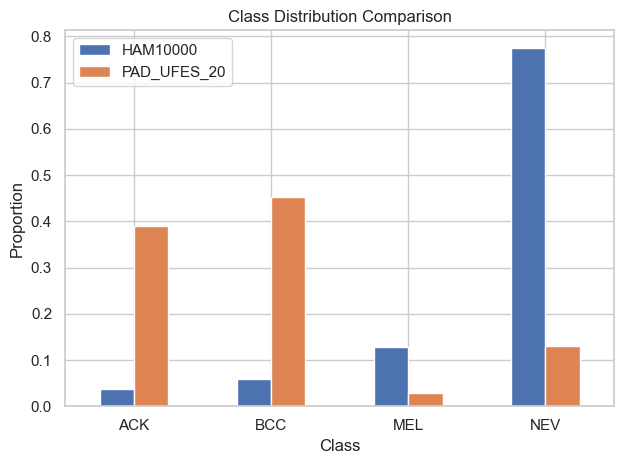

In [13]:
plt.figure(figsize=(8, 5))
class_dist[["HAM10000", "PAD_UFES_20"]].plot(kind="bar")
plt.title("Class Distribution Comparison")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

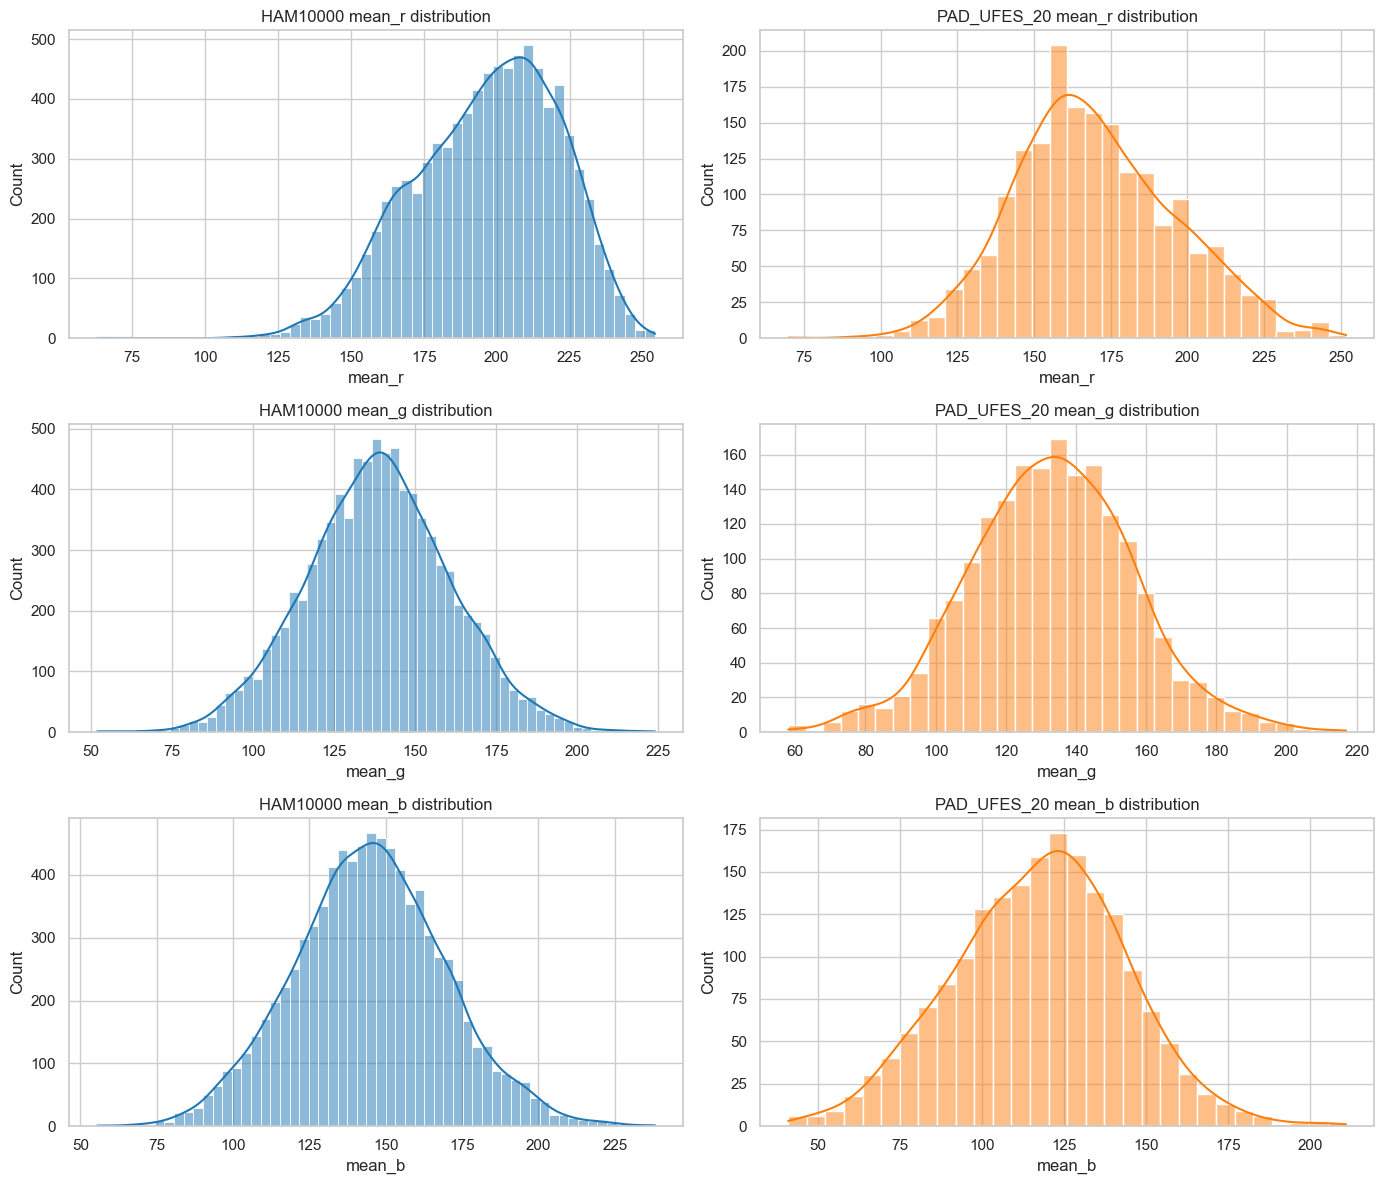

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, col in enumerate(["mean_r", "mean_g", "mean_b"]):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]

    sns.histplot(data=ham_stats, x=col, kde=True, ax=ax1, color="tab:blue")
    ax1.set_title(f"HAM10000 {col} distribution")

    sns.histplot(data=pad_stats, x=col, kde=True, ax=ax2, color="tab:orange")
    ax2.set_title(f"PAD_UFES_20 {col} distribution")

plt.tight_layout()
plt.savefig(OUT_DIR / "rgb_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

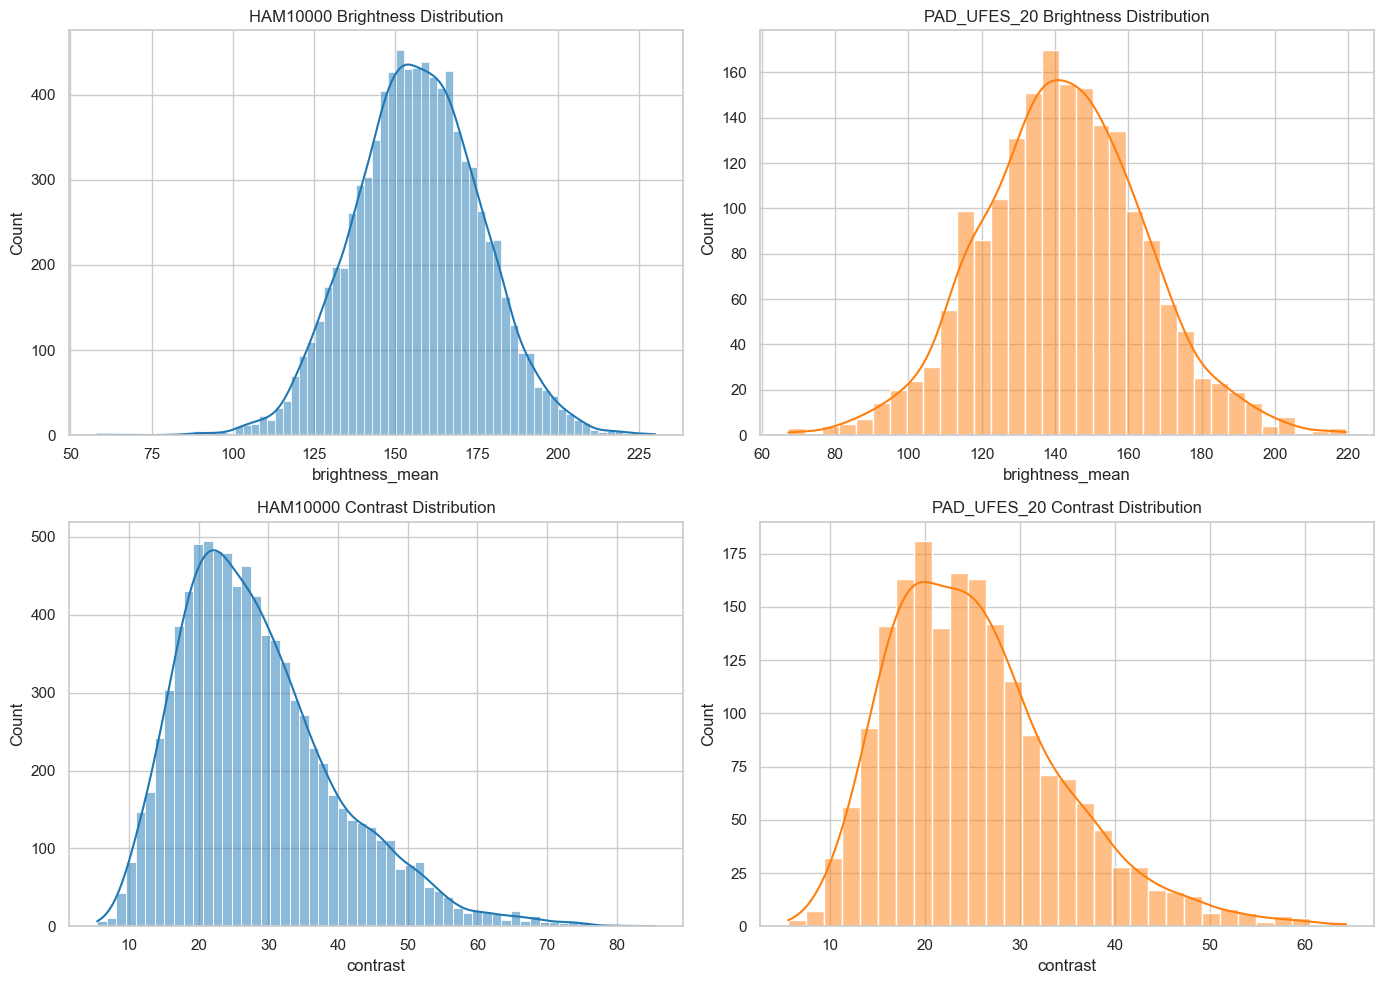

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=ham_stats, x="brightness_mean", kde=True, ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("HAM10000 Brightness Distribution")

sns.histplot(data=pad_stats, x="brightness_mean", kde=True, ax=axes[0, 1], color="tab:orange")
axes[0, 1].set_title("PAD_UFES_20 Brightness Distribution")

sns.histplot(data=ham_stats, x="contrast", kde=True, ax=axes[1, 0], color="tab:blue")
axes[1, 0].set_title("HAM10000 Contrast Distribution")

sns.histplot(data=pad_stats, x="contrast", kde=True, ax=axes[1, 1], color="tab:orange")
axes[1, 1].set_title("PAD_UFES_20 Contrast Distribution")

plt.tight_layout()
plt.savefig(OUT_DIR / "brightness_contrast_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

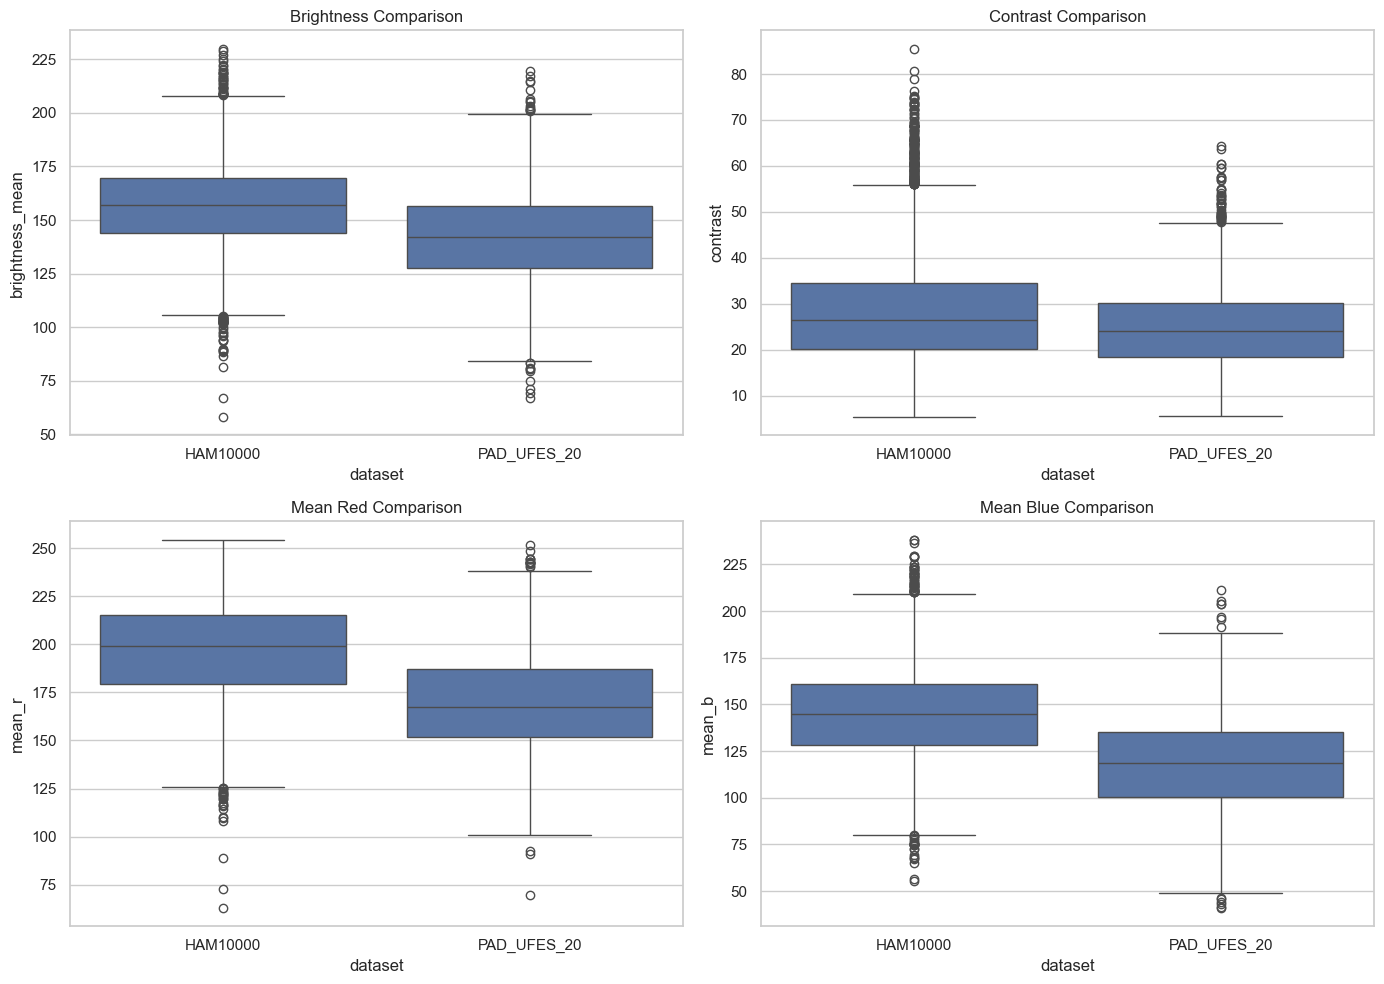

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=all_stats, x="dataset", y="brightness_mean", ax=axes[0, 0])
axes[0, 0].set_title("Brightness Comparison")

sns.boxplot(data=all_stats, x="dataset", y="contrast", ax=axes[0, 1])
axes[0, 1].set_title("Contrast Comparison")

sns.boxplot(data=all_stats, x="dataset", y="mean_r", ax=axes[1, 0])
axes[1, 0].set_title("Mean Red Comparison")

sns.boxplot(data=all_stats, x="dataset", y="mean_b", ax=axes[1, 1])
axes[1, 1].set_title("Mean Blue Comparison")

plt.tight_layout()
plt.savefig(OUT_DIR / "boxplots_key_features.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
resolution_summary = all_stats.groupby("dataset").agg(
    median_width=("width", "median"),
    median_height=("height", "median"),
    mean_width=("width", "mean"),
    mean_height=("height", "mean"),
    median_aspect_ratio=("aspect_ratio", "median"),
    mean_aspect_ratio=("aspect_ratio", "mean")
).reset_index()

resolution_summary.to_csv(OUT_DIR / "resolution_summary.csv", index=False)
print(resolution_summary)

       dataset  median_width  median_height  mean_width  mean_height  \
0     HAM10000         600.0          450.0   600.00000   450.000000   
1  PAD_UFES_20         779.0          779.0   949.39551   949.297702   

   median_aspect_ratio  mean_aspect_ratio  
0             1.333333           1.333333  
1             1.000000           1.000245  


In [18]:
summary_dict = {
    "summary": summary.to_dict(orient="records"),
    "resolution_summary": resolution_summary.to_dict(orient="records"),
    "class_distribution": class_dist.reset_index().to_dict(orient="records")
}

with open(OUT_DIR / "dataset_characterization_summary.json", "w") as f:
    json.dump(summary_dict, f, indent=2)

print("Saved summary JSON.")

Saved summary JSON.


In [19]:
print("\n--- DATASET CHARACTERIZATION REPORT ---\n")

for _, row in summary.iterrows():
    print(f"Dataset: {row['dataset']}")
    print(f"  Num images: {row['num_images']}")
    print(f"  Mean RGB: ({row['mean_r']:.2f}, {row['mean_g']:.2f}, {row['mean_b']:.2f})")
    print(f"  Mean brightness: {row['mean_brightness']:.2f}")
    print(f"  Mean contrast: {row['mean_contrast']:.2f}")
    print(f"  Median size: {row['median_width']:.0f} x {row['median_height']:.0f}")
    print(f"  Median aspect ratio: {row['median_aspect_ratio']:.3f}")
    print()


--- DATASET CHARACTERIZATION REPORT ---

Dataset: HAM10000
  Num images: 8659
  Mean RGB: (196.68, 138.93, 144.81)
  Mean brightness: 156.86
  Mean contrast: 28.43
  Median size: 600 x 450
  Median aspect ratio: 1.333

Dataset: PAD_UFES_20
  Num images: 1871
  Mean RGB: (169.90, 132.98, 117.59)
  Mean brightness: 142.27
  Mean contrast: 25.27
  Median size: 779 x 779
  Median aspect ratio: 1.000



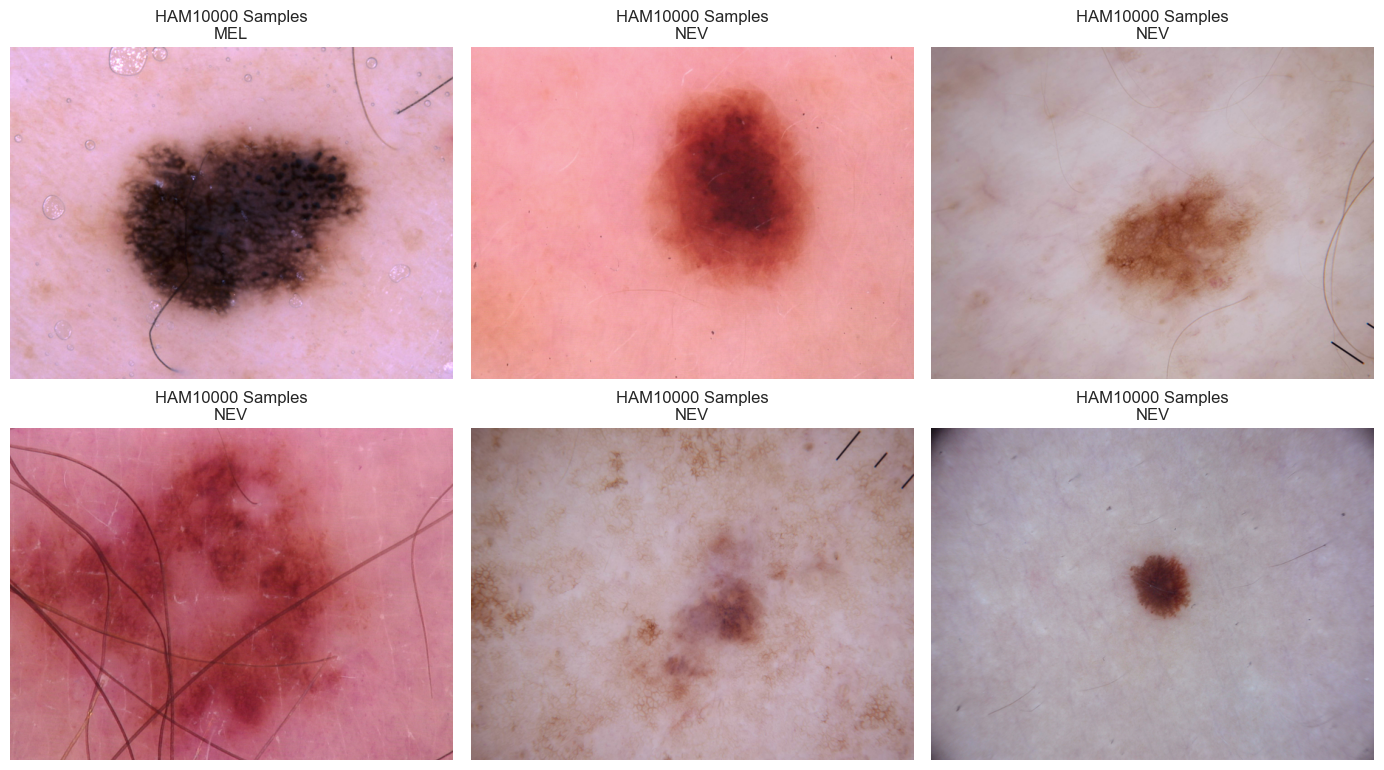

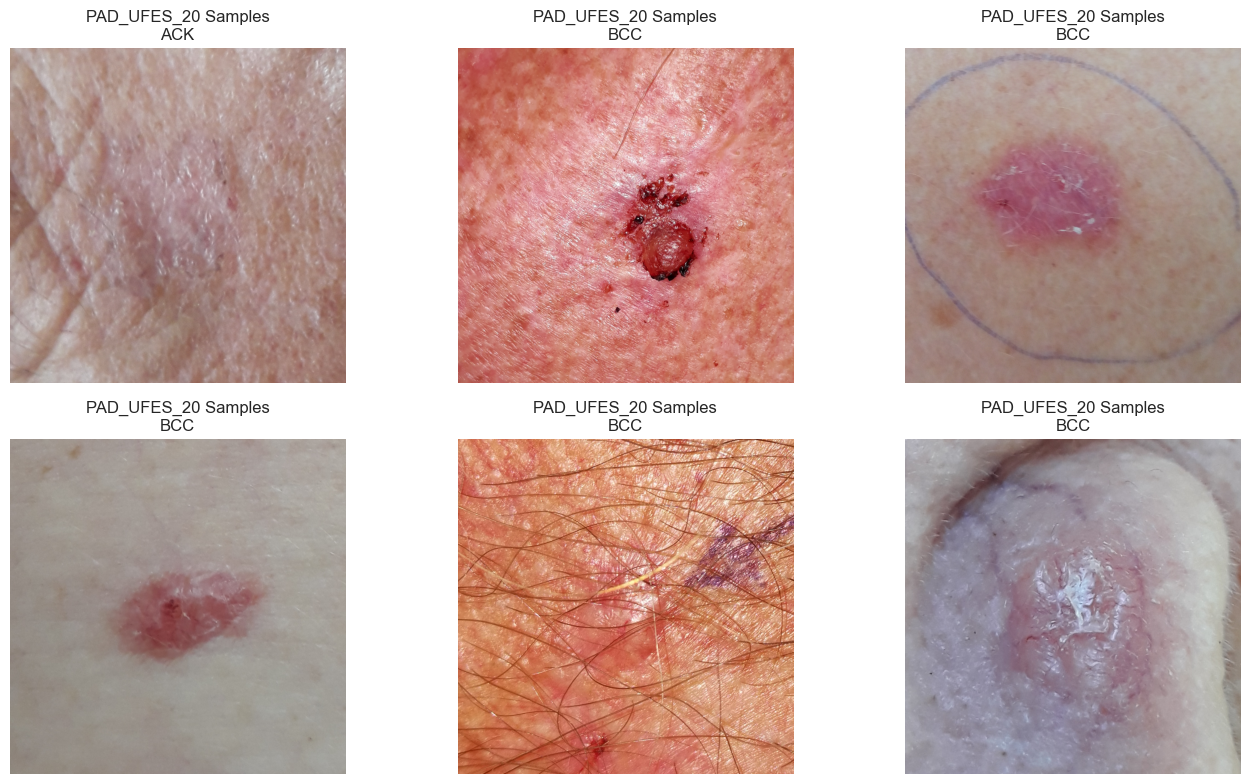

In [20]:
def show_samples(df, title, n=6):
    sample_df = df.sample(min(n, len(df)), random_state=42)
    plt.figure(figsize=(14, 8))
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(f"{title}\n{row['label']}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(ham_stats, "HAM10000 Samples", n=6)
show_samples(pad_stats, "PAD_UFES_20 Samples", n=6)